In [1]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.simplefilter('ignore', ConvergenceWarning)

# StatsForecast (AutoARIMA)
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string


In [ ]:
df = pd.read_csv(r'E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df = df.set_index('Local Time').sort_index()

# PM2.5 theo ngày
df_pm25_daily = df[['PM25']].resample('D').mean().asfreq('D')

# train/test 80/20
cutoff = int(len(df_pm25_daily) * 0.8)
train = df_pm25_daily.iloc[:cutoff, 0] 
test  = df_pm25_daily.iloc[cutoff:, 0]  
print("train:", train.shape, "test:", test.shape)

train: (584,) test: (147,)


In [5]:
def get_forecast_kpis(test_series: pd.Series, forecast_series: pd.Series) -> pd.DataFrame:
    common_idx = test_series.index.intersection(forecast_series.index)
    actual = test_series.loc[common_idx].astype(float)
    forecast = forecast_series.loc[common_idx].astype(float)

    mean_actual = actual.mean()
    bias = np.mean(forecast - actual)
    mae  = np.mean(np.abs(forecast - actual))
    rmse = np.sqrt(np.mean((forecast - actual) ** 2))

    kpis = {
        'Bias': bias,
        'Bias%': (bias / mean_actual * 100) if mean_actual != 0 else np.nan,
        'MAE': mae,
        'MAE%': (mae / mean_actual * 100) if mean_actual != 0 else np.nan,
        'RMSE': rmse,
        'RMSE%': (rmse / mean_actual * 100) if mean_actual != 0 else np.nan,
    }
    return pd.DataFrame([kpis]).round(3)

In [7]:
def get_differencing_order_d(train_series: pd.Series, max_diff: int = 10) -> int:
    s = train_series.dropna().copy()
    d = 0
    for _ in range(max_diff):
        try:
            adf_p = adfuller(s, autolag='AIC')[1]
        except Exception:
            adf_p = 1.0
        if adf_p < 0.05:
            break
        s = s.diff().dropna()
        d += 1
    return d

def get_differencing_order_D(train_series: pd.Series, season_len: int = 7) -> int:
    Fs = 0.0
    s = train_series.dropna()
    if len(s) >= 3 * season_len:
        stl = STL(s, period=season_len, robust=True).fit()
        season, resid = stl.seasonal, stl.resid
        num = np.var(resid, ddof=1)
        den = np.var(resid + season, ddof=1)
        Fs = max(0.0, 1.0 - (num / den if den > 0 else 1.0))
    return 1 if Fs > 0.6 else 0

In [6]:
def plot_acf_pacf(train_series: pd.Series, d: int, D: int, season_len: int = 7) -> None:
    s = train_series.copy()
    if d > 0:
        s = s.diff(d)
    if D > 0:
        s = s.diff(season_len)
    s = s.dropna()
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(s, lags=60, ax=ax[0])
    plot_pacf(s, lags=60, ax=ax[1], method='ywm')
    ax[0].set_title('ACF')
    ax[1].set_title('PACF')
    plt.tight_layout()
    plt.show()

In [8]:
def sarima_grid_search(
    train_series: pd.Series,
    d: int,
    D: int,
    season_len: int = 7,
    p_range=range(0, 3),
    q_range=range(0, 3),
    P_range=range(0, 3),
    Q_range=range(0, 3)
) -> tuple:
    n = len(train_series.dropna())
    candidates = []
    for p in p_range:
        for q in q_range:
            for P in P_range:
                for Q in Q_range:
                    try:
                        fit = SARIMAX(
                            train_series,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, season_len),
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        ).fit(disp=False)

                        k = fit.params.shape[0]
                        aic = fit.aic
                        aicc = aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf
                        lag = season_len if season_len < n // 2 else max(1, n // 4)
                        lb = acorr_ljungbox(fit.resid.dropna(), lags=[lag], return_df=True)
                        lb_ok = (lb["lb_pvalue"] > 0.05).all()

                        candidates.append((aicc, lb_ok, (p, d, q), (P, D, Q, season_len), fit))
                    except Exception:
                        continue

    if not candidates:
        raise RuntimeError("No SARIMA fits succeeded.")
    valid = [c for c in candidates if c[1]]
    best = min(valid, key=lambda x: x[0]) if valid else min(candidates, key=lambda x: x[0])
    return best


In [9]:
def forecast_and_plot_sarima(train_series, test_series, fitted_model, steps):
    fcst_res = fitted_model.get_forecast(steps=steps)
    fcst_df = fcst_res.summary_frame()
    fcst_mean = fcst_df['mean']

    plt.figure(figsize=(10, 5))
    plt.plot(train_series, label="Train")
    plt.plot(test_series, label="Test")
    plt.plot(fcst_mean, label="Forecast")
    plt.fill_between(fcst_df.index, fcst_df['mean_ci_lower'], fcst_df['mean_ci_upper'], alpha=0.25)
    plt.axvline(train_series.index[-1], linestyle="--", alpha=0.4)
    plt.title(f"SARIMA Forecast ({steps}-step horizon, ±95% CI)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return fcst_mean


In [10]:
def autoarima_statsforecast_pipeline(train_df, test_df, season_len=7, steps=22):
    train_df["date"] = pd.to_datetime(train_df["date"], errors="coerce")
    test_df["date"]  = pd.to_datetime(test_df["date"], errors="coerce")

    train_sf = (
        train_df.rename(columns={"date": "ds", "total_sales": "y"})
        .assign(unique_id="series")[["unique_id", "ds", "y"]]
    )
    freq = pd.infer_freq(train_sf["ds"]) or "D"

    sf_model = StatsForecast(models=[AutoARIMA(season_length=season_len)], freq=freq, n_jobs=-1)
    fitted_model = sf_model.fit(train_sf)
    forecast_sf = fitted_model.predict(h=steps)

    fitted_orders = fitted_model.fitted_[0][0]
    print("AutoARIMA model structure:")
    print(arima_string(fitted_orders.model_))

    test_sf = test_df.rename(columns={"date": "ds", "total_sales": "y"})[["ds", "y"]]

    plt.figure(figsize=(12, 6))
    plt.plot(train_sf["ds"], train_sf["y"], label="Train", color="blue")
    plt.plot(test_sf["ds"], test_sf["y"], label="Test", color="red")
    plt.plot(forecast_sf["ds"], forecast_sf["AutoARIMA"], label="Forecast", color="green")
    plt.axvline(train_sf["ds"].max(), color="gray", linestyle="--", alpha=0.6)
    plt.title(f"StatsForecast AutoARIMA Forecast ({steps}-step horizon)")
    plt.xlabel("Date"); plt.ylabel("Value"); plt.legend(); plt.tight_layout(); plt.show()

    return train_sf, test_sf, forecast_sf


AutoARIMA model structure:
ARIMA(3,1,3)                   


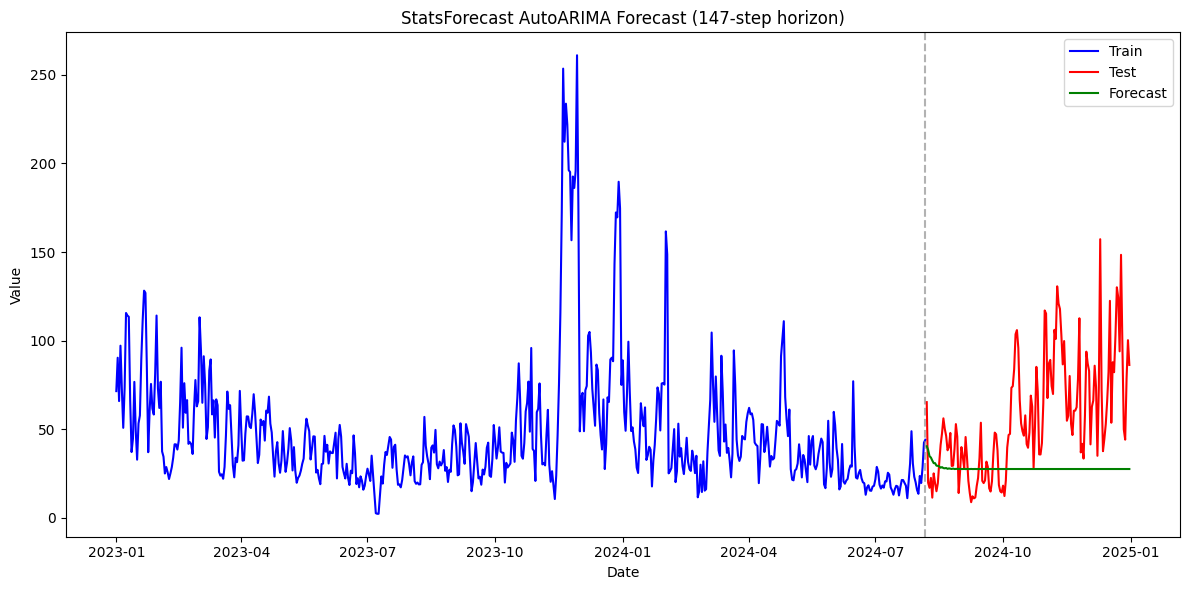

d = 0, D = 0


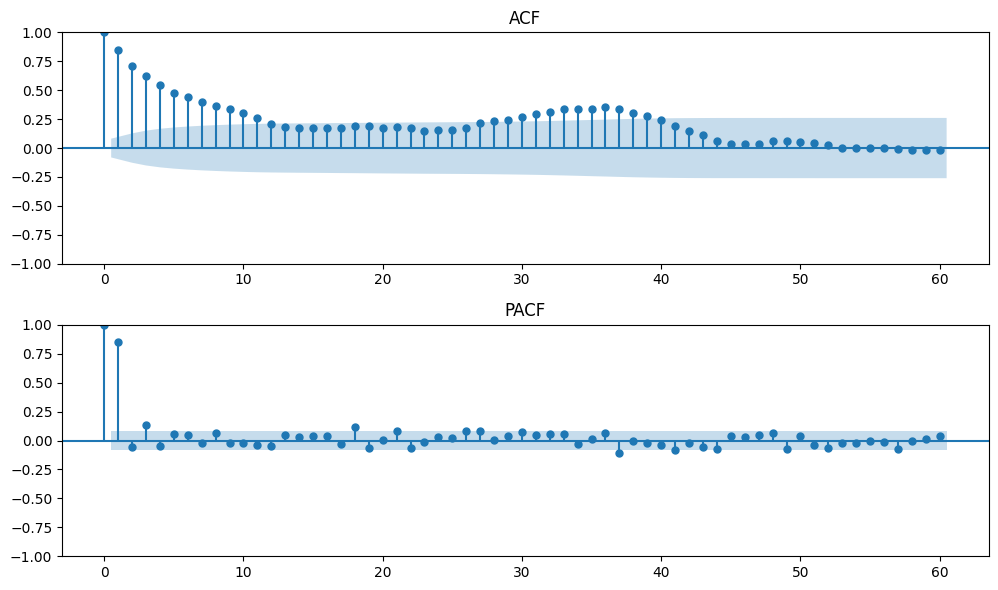

Best AICc: 4920.9792419549185 | Ljung-Box ok: True | Orders: (1, 0, 2) | Seasonal: (2, 0, 2, 7)


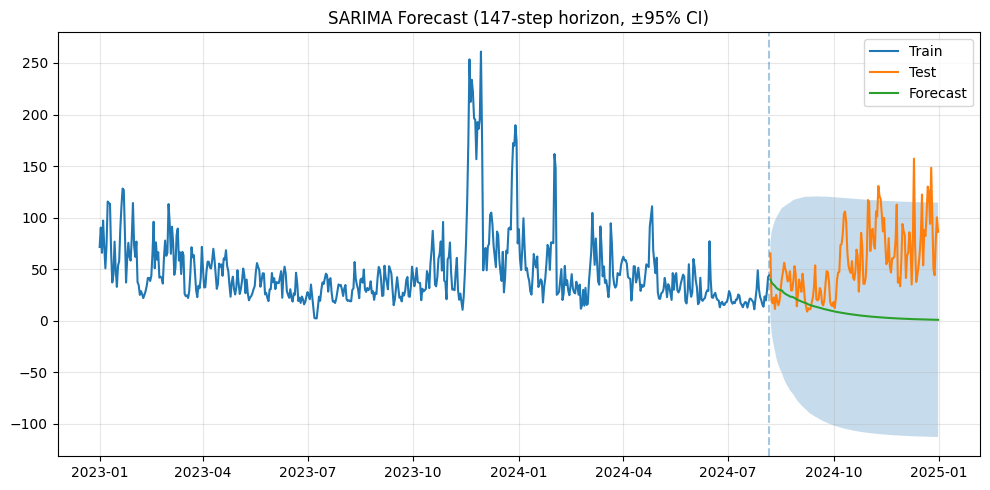

In [11]:
# Chuẩn hóa dữ liệu cho AutoARIMA
df_pm25_train = train.to_frame(name="PM25")
df_pm25_test  = test.to_frame(name="PM25")

train_df = df_pm25_train.reset_index().rename(columns={"Local Time": "date", "PM25": "total_sales"})
test_df  = df_pm25_test.reset_index().rename(columns={"Local Time": "date", "PM25": "total_sales"})

# AutoARIMA
train_sf, test_sf, forecast_sf = autoarima_statsforecast_pipeline(
    train_df=train_df,
    test_df=test_df,
    season_len=7,
    steps=len(test_df)
)

# SARIMA
season_len = 7
d = get_differencing_order_d(train)
D = get_differencing_order_D(train, season_len=season_len)
print(f"d = {d}, D = {D}")

plot_acf_pacf(train, d=d, D=D, season_len=season_len)
best = sarima_grid_search(train, d=d, D=D, season_len=season_len)
print("Best AICc:", best[0], "| Ljung-Box ok:", best[1], "| Orders:", best[2], "| Seasonal:", best[3])

sarima_forecast = forecast_and_plot_sarima(train, test, best[4], steps=len(test))


In [12]:
print("Forecasting KPIs – SARIMA")
print(get_forecast_kpis(test_series=test, forecast_series=sarima_forecast))

print("Forecasting KPIs – AutoARIMA (StatsForecast)")
auto_series = pd.Series(forecast_sf["AutoARIMA"].values, index=forecast_sf["ds"])
test_series = pd.Series(test_sf["y"].values, index=test_sf["ds"])
print(get_forecast_kpis(test_series=test_series, forecast_series=auto_series))


Forecasting KPIs – SARIMA
     Bias   Bias%     MAE    MAE%    RMSE    RMSE%
0 -46.756 -82.603  48.718  86.069  60.729  107.288
Forecasting KPIs – AutoARIMA (StatsForecast)
    Bias   Bias%     MAE    MAE%    RMSE   RMSE%
0 -28.61 -50.545  33.295  58.821  43.598  77.024
